# 03 · Gaza, four panels

Radar · UNOSAT labels · model prediction · PWTT prediction, over the whole strip.

Whole-tile inference, not patch-wise: during training a footprint straddling two
patch cores gets pooled twice over partial pixel sets, which is fine as a gradient
signal but not good enough for a map.

In [1]:
!pip install -q rasterio

In [2]:
import glob, os
import numpy as np, rasterio, torch, matplotlib.pyplot as plt
import torch.nn as nn, torch.nn.functional as F
from matplotlib.colors import ListedColormap
from sklearn.metrics import precision_recall_curve

from google.colab import drive
drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

TILE_DIR = '/content/drive/MyDrive/s1_bda_labelled'
CKPT     = '/content/drive/MyDrive/siamese_unet.pt'

PIX_M, CORE_PX, HALO_PX = 10, 50, 15
ORBITS, IN_CH = 2, 12
BAND_ORDER = ([f'{p}_o{o}_{b}' for p in ('pre','post') for o in range(ORBITS)
               for b in ('VV_mean','VV_sd','VH_mean','VH_sd','n','valid')]
              + ['fid', 'label', 'area', 'gx', 'gy'])
BI = {n: i for i, n in enumerate(BAND_ORDER)}
DB_OFFSET, DB_SCALE, SD_SCALE, N_SCALE = -12.0, 8.0, 3.0, 5.0

def normalize(x):
    out = x.copy()
    for o in range(ORBITS):
        b = o * 6
        out[b+0] = (x[b+0] - DB_OFFSET) / DB_SCALE
        out[b+1] =  x[b+1] / SD_SCALE
        out[b+2] = (x[b+2] - DB_OFFSET) / DB_SCALE
        out[b+3] =  x[b+3] / SD_SCALE
        out[b+4] = np.log1p(np.maximum(x[b+4], 0)) / N_SCALE
    return np.nan_to_num(out, nan=0., posinf=0., neginf=0.)

Mounted at /content/drive


## Model

Same definition as notebook 02 — needed to load the checkpoint.

In [3]:
def disc(r):
    y, x = torch.meshgrid(torch.arange(-r, r+1, dtype=torch.float32),
                          torch.arange(-r, r+1, dtype=torch.float32), indexing='ij')
    k = ((x**2 + y**2) <= r**2).float()
    return (k / k.sum())[None, None]

KERNELS = {r: disc(r).to(device) for r in (5, 10, 15)}
crop = lambda x: x[..., HALO_PX:HALO_PX+CORE_PX, HALO_PX:HALO_PX+CORE_PX]

def smooth(x):
    return torch.stack([x] + [F.conv2d(F.pad(x, (r,)*4, mode='reflect'), k)
                              for r, k in KERNELS.items()]).mean(0)

def block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU(True),
                         nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU(True))

class SiameseUNet(nn.Module):
    def __init__(self, base=32, depth=4):
        super().__init__()
        self.depth = depth
        ch = [base * 2**i for i in range(depth + 1)]
        self.enc = nn.ModuleList([block(c, o) for c, o in zip([IN_CH] + ch[:-2], ch[:-1])])
        self.mid = block(ch[-2] * 3, ch[-1])
        self.up  = nn.ModuleList([nn.ConvTranspose2d(ch[i+1], ch[i], 2, 2)
                                  for i in reversed(range(depth))])
        self.dec = nn.ModuleList([block(ch[i] * 4, ch[i]) for i in reversed(range(depth))])
        self.head = nn.Conv2d(base, 1, 1)

    def encode(self, x):
        skips = []
        for b in self.enc:
            x = b(x); skips.append(x); x = F.max_pool2d(x, 2)
        return skips, x

    def forward(self, pre, post):
        sa, a = self.encode(pre); sb, b = self.encode(post)
        x = self.mid(torch.cat([a, b, (a-b).abs()], 1))
        for i, (up, dec) in enumerate(zip(self.up, self.dec)):
            l = self.depth - 1 - i
            x = dec(torch.cat([up(x), sa[l], sb[l], (sa[l]-sb[l]).abs()], 1))
        return crop(smooth(self.head(x)))

model = SiameseUNet().to(device)
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck['model']); model.eval()
print('checkpoint AUC', round(ck['metrics']['AUC'], 2))

checkpoint AUC 85.92


## Inference over every tile

The 80×80 window slides with a 50 px stride; only the 500 m cores are written out,
so the stitched raster has no seams and every pixel was predicted with its full
150 m of context. The PWTT is recomputed from the same bands for panel 4.

In [4]:
def pwtt_T(pre, post):
    ts = []
    for o in range(ORBITS):
        b = o*6
        n0, n1 = pre[:, b+4:b+5].clamp(min=2), post[:, b+4:b+5].clamp(min=2)
        valid  = pre[:, b+5:b+6] * post[:, b+5:b+6]
        for p in range(2):
            m0, s0 = pre[:, b+2*p:b+2*p+1],  pre[:, b+2*p+1:b+2*p+2]
            m1, s1 = post[:, b+2*p:b+2*p+1], post[:, b+2*p+1:b+2*p+2]
            ts.append(((m0-m1) / (s0**2/n0 + s1**2/n1).clamp(min=1e-6).sqrt()).abs() * valid)
    return torch.stack(ts).max(0).values

@torch.no_grad()
def infer(path, batch=32):
    with rasterio.open(path) as src:
        arr = src.read().astype('float32')
        bounds = src.bounds
    _, H, W = arr.shape
    pad = ((0,0), (HALO_PX, HALO_PX+CORE_PX), (HALO_PX, HALO_PX+CORE_PX))
    padded = np.pad(arr[:2*IN_CH], pad, mode='reflect')

    out = np.zeros((H, W), 'float32')
    wins, xy = [], []
    def flush():
        if not wins: return
        st = np.stack(wins)
        p = torch.from_numpy(st[:, :IN_CH]).to(device)
        q = torch.from_numpy(st[:, IN_CH:]).to(device)
        lg = model(p, q).squeeze(1).cpu().numpy()
        for (r, c), t in zip(xy, lg):
            h, w = min(CORE_PX, H-r), min(CORE_PX, W-c)
            out[r:r+h, c:c+w] = t[:h, :w]
        wins.clear(); xy.clear()

    for r in range(0, H, CORE_PX):
        for c in range(0, W, CORE_PX):
            win = padded[:, r:r+CORE_PX+2*HALO_PX, c:c+CORE_PX+2*HALO_PX]
            wins.append(np.concatenate([normalize(win[:IN_CH]), normalize(win[IN_CH:])]))
            xy.append((r, c))
            if len(wins) == batch: flush()
    flush()

    raw = torch.from_numpy(arr[None, :2*IN_CH]).to(device)
    T = smooth(pwtt_T(raw[:, :IN_CH], raw[:, IN_CH:]))[0,0].cpu().numpy()
    return arr, out, T, bounds

In [5]:
tiles = sorted(p for p in glob.glob(f'{TILE_DIR}/*.tif') if not p.endswith('_s1.tif'))
res = {}
for p in tiles:
    res[p] = infer(p)
    print('done', os.path.basename(p))

done gaza_000.tif
done gaza_001.tif
done gaza_002.tif
done gaza_003.tif


## Footprint-level scores

Pool each raster over complete footprints, pick the threshold that maximises
area-weighted F1 — the paper's procedure — and paint the binary result back onto
the pixels for mapping.

In [6]:
def pool_and_threshold(score_raster, arr):
    fid = arr[BI['fid']].astype('int64').ravel()
    lab = arr[BI['label']].ravel()
    w   = arr[BI['area']].ravel()
    ids, inv = np.unique(fid, return_inverse=True)
    s = np.bincount(inv, weights=score_raster.ravel()) / np.maximum(np.bincount(inv), 1)
    y = np.zeros(len(ids)); np.maximum.at(y, inv, lab)
    a = np.zeros(len(ids)); np.maximum.at(a, inv, w)
    keep = ids != 0
    return s[keep], y[keep], np.maximum(a[keep], 100.), ids[keep], inv, fid

# gather every footprint across all tiles to pick one global threshold each
def collect(idx):
    S, Y, A = [], [], []
    for p, (arr, unet, T, _) in res.items():
        r = [unet, T][idx]
        s, y, a, *_ = pool_and_threshold(r, arr)
        S.append(s); Y.append(y); A.append(a)
    return np.concatenate(S), np.concatenate(Y), np.concatenate(A)

def best_thr(s, y, w):
    p, r, t = precision_recall_curve(y, s, sample_weight=w)
    return float(t[int(np.nanargmax((2*p*r/np.maximum(p+r,1e-9))[:-1]))])

thr_unet = best_thr(*collect(0))
thr_pwtt = best_thr(*collect(1))
print(f'thresholds  model {thr_unet:.3f}   PWTT {thr_pwtt:.3f}')

thresholds  model 1.949   PWTT 4.277


## The four panels

Mosaicked into one canvas covering the strip. Footprints are ~4 pixels each, so at
full-strip zoom individual buildings are subpixel — the maps read as damage
density, which is the scale the paper's Fig. 5 and Fig. 8 use too.

In [7]:
# common canvas from tile bounds
b = [res[p][3] for p in tiles]
left, right = min(x.left for x in b), max(x.right for x in b)
bottom, top = min(x.bottom for x in b), max(x.top for x in b)
Wc, Hc = int((right-left)//PIX_M), int((top-bottom)//PIX_M)

radar = np.full((Hc, Wc), np.nan, 'float32')
truth = np.full((Hc, Wc), np.nan, 'float32')
pred  = np.full((Hc, Wc), np.nan, 'float32')
pwtt  = np.full((Hc, Wc), np.nan, 'float32')

for p in tiles:
    arr, unet, T, bd = res[p]
    r0 = int((top - bd.top)//PIX_M); c0 = int((bd.left - left)//PIX_M)
    h, w = arr.shape[1], arr.shape[2]
    sl = (slice(r0, r0+h), slice(c0, c0+w))

    fid = arr[BI['fid']]
    m = fid > 0
    radar[sl] = arr[IN_CH]                                    # post VV mean, dB
    truth[sl] = np.where(m, arr[BI['label']], np.nan)

    for raster, thr, dest in [(unet, thr_unet, pred), (T, thr_pwtt, pwtt)]:
        s, y, a, ids, inv, flat = pool_and_threshold(raster, arr)
        lut = np.zeros(int(flat.max())+1); lut[ids.astype(int)] = (s > thr)
        dest[sl] = np.where(m, lut[fid.astype(int)], np.nan)

print(f'canvas {Hc} x {Wc} px')

canvas 3966 x 3334 px


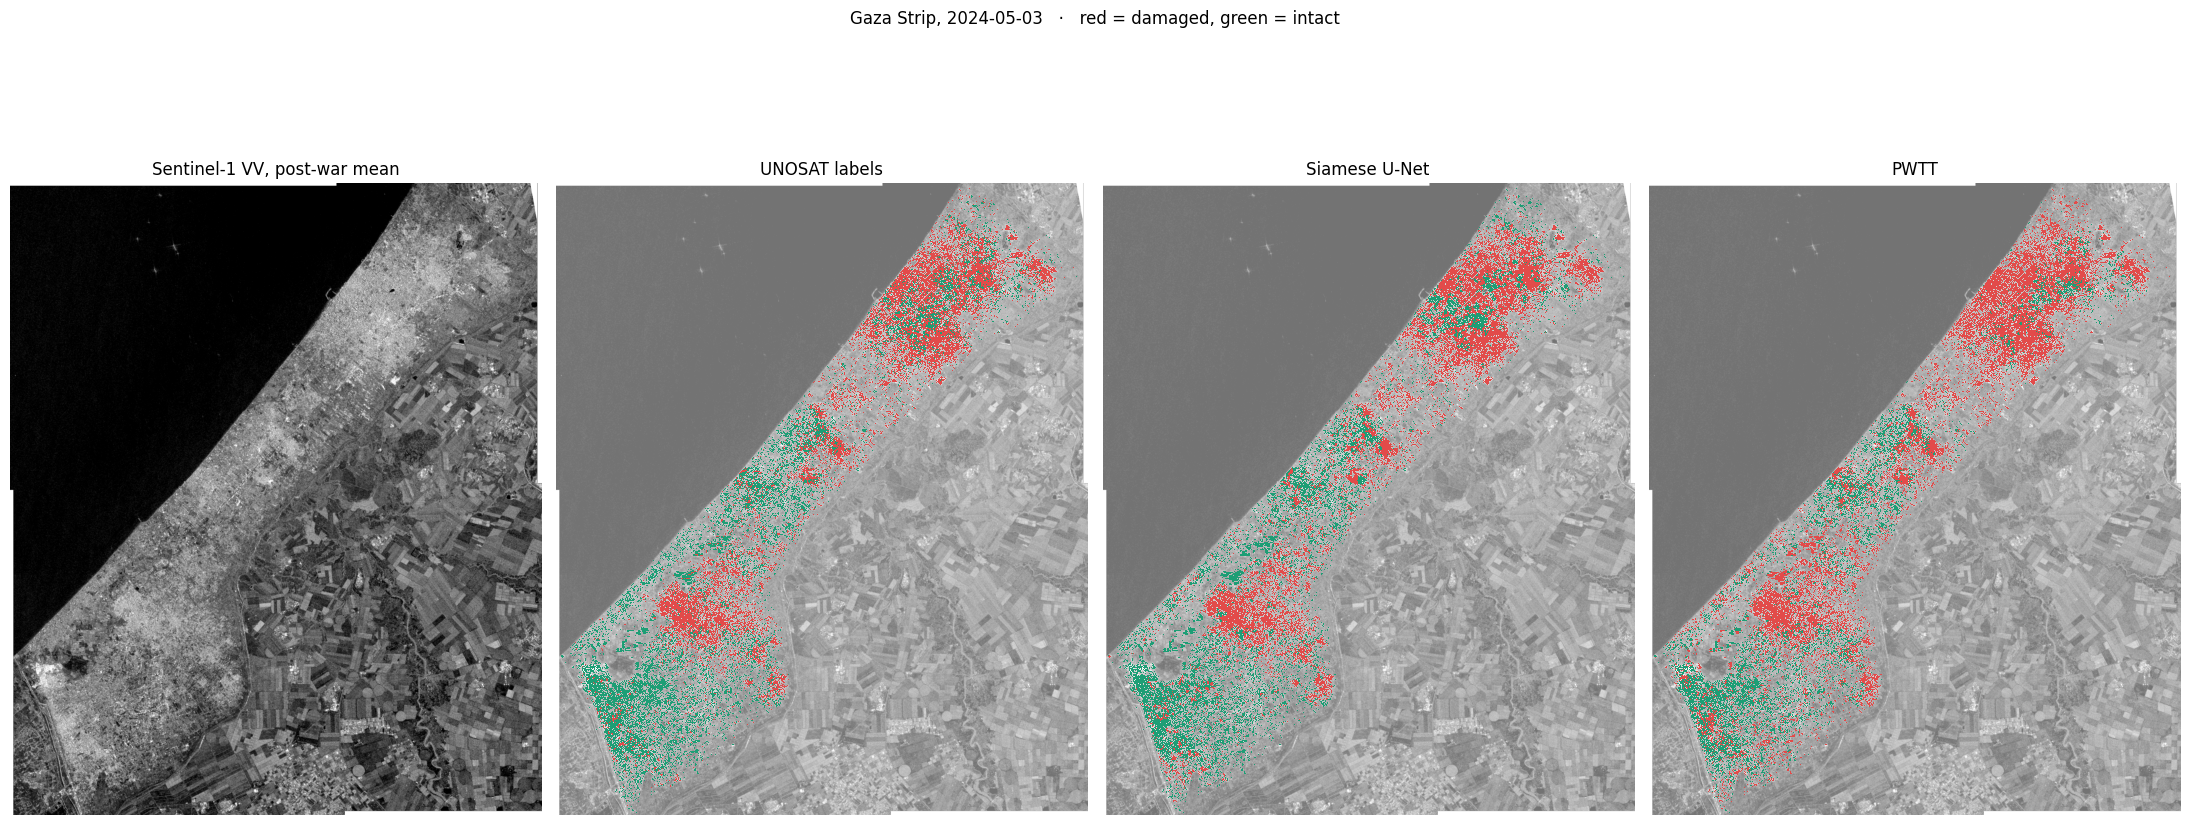

In [8]:
dmg = ListedColormap(['#1D9E75', '#E24B4A'])      # undamaged green, damaged red

fig, ax = plt.subplots(1, 4, figsize=(22, 11))
ax[0].imshow(radar, cmap='gray', vmin=-22, vmax=0)
ax[0].set_title('Sentinel-1 VV, post-war mean')

for a, d, t in [(ax[1], truth, 'UNOSAT labels'),
                (ax[2], pred,  'Siamese U-Net'),
                (ax[3], pwtt,  'PWTT')]:
    a.imshow(radar, cmap='gray', vmin=-22, vmax=0, alpha=.55)
    a.imshow(d, cmap=dmg, vmin=0, vmax=1, interpolation='nearest')
    a.set_title(t)

for a in ax: a.axis('off')
fig.suptitle('Gaza Strip, 2024-05-03   ·   red = damaged, green = intact', y=.93)
plt.tight_layout(); plt.savefig('/content/drive/MyDrive/gaza_panels.png', dpi=150,
                                bbox_inches='tight')
plt.show()

## Agreement

In [9]:
ok = ~np.isnan(truth) & ~np.isnan(pred)
for name, d in [('Siamese U-Net', pred), ('PWTT', pwtt)]:
    agree = (d[ok] == truth[ok]).mean()
    print(f'{name:15s} pixel-level agreement with UNOSAT: {100*agree:.1f}%  '
          f'| predicted damaged: {100*d[ok].mean():.1f}%  '
          f'(actual {100*truth[ok].mean():.1f}%)')

Siamese U-Net   pixel-level agreement with UNOSAT: 77.6%  | predicted damaged: 54.1%  (actual 50.8%)
PWTT            pixel-level agreement with UNOSAT: 71.2%  | predicted damaged: 64.9%  (actual 50.8%)


Read the maps rather than the agreement number: what matters is whether the two
prediction panels put damage in the same *places* as the label panel. Both are
expected to over-predict extent — Section 3.3 of the paper finds most false
positives sit within ~30 m of genuine damage, so the predicted areas look like
slightly swollen versions of the true ones rather than damage invented elsewhere.

Also worth remembering when reading panel 3: the model saw the northern half of
the strip during training, so the southern half is the only part that is an
honest test.